In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sympy.abc import x, y
from scipy.sparse.linalg import cg
import torch
import torch.nn as nn
from torch.autograd import Variable
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
torch.pi = torch.acos(torch.zeros(1)).item() * 2
print(f"Using {DEVICE} device")

Using cuda device


In [2]:
class NeuralNet(nn.Module):
    def __init__(self, hidden_layers, hidden_input = 5):
        super(NeuralNet, self).__init__()

        layers = [
                nn.Linear(2,hidden_input),
                nn.Tanh()
                ]
        
        for _ in range(hidden_layers):
            layers.append(nn.Linear(hidden_input,hidden_input))
            layers.append(nn.Tanh())
            
        layers.append(nn.Linear(hidden_input, 1))
        self.network = nn.Sequential(*layers)


    def forward(self, x, y):
        '''
            where x.shape = y.shape = (pts,1)
        '''
        input_vec = torch.cat([x,y],axis=1)
        return self.network(input_vec) # input_vec should be smth like input_vec.shape = nrows x 2,
                                       # where each row is a (x,y) pair which is the input for nn.Linear  

# Numerical Approximation

Implementation of conjugate gradient method to solve poisson's equation in 2 dimensions. <br>
The PDE we are given to solve: 
$$
       \nabla^2 u = f, \qquad u(x,0) = u(x,1) = u(0,t) = u(1,t) = 0
$$
But note that we can rewrite it in the following approximated form using centered difference in both the $x$ and $t$ direction denoted by $i$ and $j$ respectively:
$$
    \nabla^2 u = u_{xx} + u_{tt} \approx \frac{u_{i+1,\, j} - u_{i-1,\, j}}{2\Delta x} + \frac{u_{i,\, j+1} - u_{i,\, j-1}}{2\Delta t} = f
$$
For simplicity we are picking delta x and delta t such that $\Delta x = \Delta t$ which we will denote as $h$. Then we get the following: 
$$
    u_{i+1,\, j} - u_{i-1,\, j} + u_{i,\, j+1} - u_{i,\, j-1} = 2h f
$$
In this case, the addition of $i$ and $j$ indicates points in the the area which we are solving Poisson's equation for. From the given PDE above, the area in this case is the unit square, so then the natural mesh for $(i,j)$ is a square mesh. <br>
<br>
From this mesh we naturally obtain a system of equations and the following matrix: 
$$A = \left[
\begin{array}{ccc|ccc|ccc}
 4 & -1 &  0 & -1 &  0 &  0 &  0 &  0 &  0 \\
-1 &  4 & -1 &  0 & -1 &  0 &  0 &  0 &  0 \\
 0 & -1 &  4 &  0 &  0 & -1 &  0 &  0 &  0 \\
\hline
-1 &  0 &  0 &  4 & -1 &  0 & -1 &  0 &  0 \\
 0 & -1 &  0 & -1 &  4 & -1 &  0 & -1 &  0 \\
 0 &  0 & -1 &  0 & -1 &  4 &  0 &  0 & -1 \\
\hline
 0 &  0 &  0 & -1 &  0 &  0 &  4 & -1 &  0 \\
 0 &  0 &  0 &  0 & -1 &  0 & -1 &  4 & -1 \\
 0 &  0 &  0 &  0 &  0 & -1 &  0 & -1 &  4 \\
\end{array}
\right]
$$

In [ ]:
def boundary_conditions_vector(n):
    # they are all zero for now
    return np.zeros(((n-2)**2,1))

def construct_b(n,h):
    f,u = toy_function(n)
    b = np.zeros((n-2,n-2))
    
    for i in range(n-2):
        for j in range(n-2):
            b[i][j] = -f[i+1][j+1]
   
    b = np.resize(b,(b.shape[0]**2,1))
    
    return ((h**2)*b + boundary_conditions_vector(n),f,u)

In [ ]:
def toy_function(n):
    '''
    Returns (z,u) where 
     - z is the function used in solving the equation 
     - u is the exact solution based off z
    '''
    
    x = np.linspace(0,1,n)
    y = np.linspace(0,1,n)
    X,Y = np.meshgrid(x,y)
    z = np.zeros((n,n))
    u = np.zeros((n,n))
    
    s = 3
    for K in range(1,s+1):
            for L in range(1,s+1):
                c = 0.5            # np.random.normal()
                z+= c*np.sin(K*np.pi*X)*np.sin(L*np.pi*Y)

                b = -c/((K*np.pi)**2 + (L*np.pi)**2)
                u += b*np.sin(K*np.pi*X)*np.sin(L*np.pi*Y)
    return (z,u)

In [ ]:
def construct_A(N):
    if (N <= 2):
        raise Exception("Matrix not needed")

    n = (N-2)**2 # the mesh works out nicely if n is a perfect square
    if ( n%np.sqrt(n) != 0 ):
        raise Exception("N-2 must be a perfect square") 
    m = np.sqrt(n) 
    
    A = np.zeros((n,n))
    m = int(m)
    
    # diagonal ------------------------------------
    for i in range(n):
        for j in range(n):
            if (i==j):
                A[i,j] = 4
    
    # the upper diagonal ---------------------------
    for k in range(m):
        for i in range(k*m, (k+1)*m-1):
            A[i,i+1] = -1
    
    # the lower diagonal ---------------------------
    for k in range(m):
        for i in range(k*m+1,(k+1)*m):
            A[i,i-1] = -1
    
    # identity matrices ----------------------------
    for i in range(m,n):
        A[i-m,i] = -1
        A[i,i-m] = -1

    return A


In [ ]:
def poisson_solver(n):
    # n is stencil
    x = np.linspace(0,1,n)
    y = np.linspace(0,1,n)
    h = 1/(n-1)
    w =  np.zeros((n,n))
    A = construct_A(n)
    b,f,u = construct_b(n,h)
    X,Y = np.meshgrid(x,y)

    z, exit_code = cg(A,b)
    z = np.resize(z,(n-2,n-2))
    w[1:n-1,1:n-1] = w[1:n-1,1:n-1] + z

    # solution 
    fig = plt.figure()
    ax = plt.axes(projection='3d')
    ax.set_title('numerical approximation')
    ax.plot_surface(X,Y,w,cmap = 'inferno')

    # toy function exact solution
    fig1 = plt.figure()
    ax1 = plt.axes(projection='3d')
    ax1.set_title('toy function exact solution')
    ax1.plot_surface(X,Y,u,cmap = 'inferno')

    # error
    error = np.abs(u-w)
    fig2 = plt.figure()
    ax2 = plt.axes(projection='3d')
    ax2.set_title('toy function exact solution')
    ax2.plot_surface(X,Y,error,cmap = 'inferno')

#poisson_solver(50)

# PINN 

The PDE we are solving is Poisson's equation in 2 dimensions with dirichlet boundary conditions: 
$$
    \nabla^2 u = f, \qquad u(x,0) = u(x,1) = u(0,t) = u(1,t) = 0
$$
Given: $$ f(x,t) =  \frac{1}{2} \sum_{K\, = \,1}^{3}\sum_{L \,= \,1}^{3} \, \sin{(K\pi x)}\sin{(L\pi t)} $$
With the PDE loss function described as:
$$
    L_{pde} = u_{xx}^2 + u_{yy}^2 - f
$$
Which we will be aiming to minimize using mean squared error loss.

In [3]:
'''
Loss function: loss functions only for the inside of the domain 
'''

from torch.autograd import grad


def pde_loss(u_pred,f,x,y):
    '''
    u is my result from my Poisson solver function (just need to make sure it's converted to a tensor
    f is the toy function i used

    pde_loss returns a difference matrix to evaluate the difference in the u and f (part of the training stages of the model)
    '''
    
    u_x = grad(
        outputs = u_pred,
        inputs = x,
        grad_outputs = torch.ones_like(u_pred),
        retain_graph = True,
        create_graph = True
    )[0]
    u_xx = grad(
        outputs = u_x,
        inputs = x,
        grad_outputs = torch.ones_like(u_x),
        create_graph = True
    )[0]
    u_y = grad(
        outputs = u_pred,
        inputs = y,
        grad_outputs = torch.ones_like(u_pred),
        retain_graph = True,
        create_graph = True
    )[0]
    u_yy = grad(
        outputs = u_y,
        inputs = y,
        grad_outputs = torch.ones_like(u_y),
        create_graph = True
    )[0]
    
    return torch.mean((u_xx + u_yy - f)**2)

In [4]:
def f(x,y,n = 50):
    '''
    X,Y are tensors or numpy arrays in a mesh? 
    n is the number of points (figure this out next time) 
    
    u is exact solution that the PINN should get 
    f is the toy function f that I am using for the PINN
    '''
    f = torch.zeros_like(x) # f.shape = x.shape = (pts,1)
    u = torch.zeros_like(x)
    s = 3
    
    for K in range(1,s+1):
            for L in range(1,s+1):
                #c = torch.randn(1).to(DEVICE)
                c = 0.5
                f+= c*torch.sin(K*torch.pi*x)*torch.sin(L*torch.pi*y)

                b = -c/((K*torch.pi)**2 + (L*torch.pi)**2)
                u += b*torch.sin(K*torch.pi*x)*torch.sin(L*torch.pi*y)
    return (f,u)

In [5]:
'''
Boundary conditions; references (https://github.com/nanditadoloi/PINN/blob/main/solve_PDE_NN.ipynb) only have 1 boundary condition, but I have four 
therefore this is my boundary conditions function. This is good im pretty sure, but I need to alter it since my boundary conditions are zero for all vals
'''

def boundary_cond(pts = 50):
    x_bc1 = torch.rand(pts,1) # rand already gets random uniform samples from a range of [0,1]
    #y_bc1 = torch.zeros(pts,1)

    #x_bc2 = torch.ones(pts,1)
    y_bc2 = torch.rand(pts,1)

    x_bc3 = torch.rand(pts,1)
    #y_bc3 = torch.ones(pts,1)

    #x_bc4 = torch.zeros(pts,1)
    y_bc4 = torch.rand(pts,1)

    return {"x_bc_values" : (x_bc1, x_bc3), "y_bc_values" : (y_bc2, y_bc4)}

In [6]:
from torch.optim import LBFGS
from torch.optim import Adam

NN = NeuralNet(hidden_layers = 5, hidden_input = 128) # 
NN.to(DEVICE)
optimizer = Adam(NN.parameters(), lr = 0.001)
loss_func = nn.MSELoss()

In [7]:
from mpl_toolkits.mplot3d import Axes3D


def plot_solution(pts=50,curr_run = 0):
    x_vals = torch.linspace(0, 1, pts).to(DEVICE)
    y_vals = torch.linspace(0, 1, pts).to(DEVICE)
    
    X_grid, Y_grid = torch.meshgrid(x_vals, y_vals, indexing='ij')
    
    # flatten for NN input to get shape [pts*pts, 1]
    x_flat = X_grid.reshape(-1, 1)
    y_flat = Y_grid.reshape(-1, 1)
    
    # NN prediction and exact solution
    NN.eval()
    with torch.no_grad():
        u_pred = NN(x_flat, y_flat).cpu().reshape(pts, pts)
    
    _, u_exact = f(x_flat, y_flat)
    u_exact = u_exact.cpu().reshape(pts, pts)
    
    X_np = X_grid.cpu().numpy()
    Y_np = Y_grid.cpu().numpy()
    u_pred_np  = u_pred.numpy()
    u_exact_np = u_exact.numpy()
    error_np   = np.abs(u_pred_np - u_exact_np)
    #############################
    if not(curr_run == 0):
        print("Graph:", curr_run)
    else:
        print("graph")
    #############################
    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), subplot_kw={'projection': '3d'})
    
    titles  = ['NN Predicted u(x,y)', 'Exact u(x,y)', 'Absolute Error']
    surfaces = [u_pred_np, u_exact_np, error_np]
    cmaps   = ['viridis', 'viridis', 'hot']
    
    for ax, Z, title, cmap in zip(axes, surfaces, titles, cmaps):
        surf = ax.plot_surface(X_np, Y_np, Z, cmap=cmap, edgecolor='none', alpha=0.9)
        ax.set_title(title, fontsize=13)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('u')
        fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
    
    plt.tight_layout()
    plt.show()

C:\Users\erick\AppData\Local\Programs\Python\Python39\lib\site-packages\torch\autograd\graph.py:829: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:179.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Graph: 1


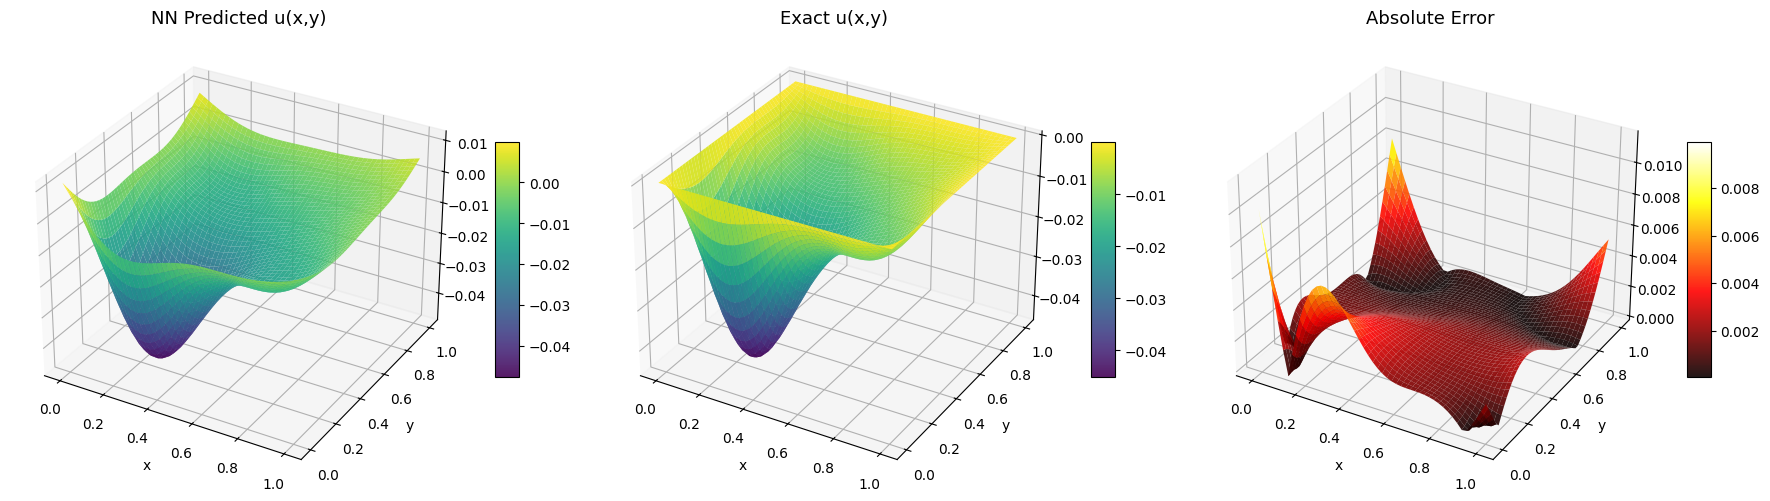

Graph: 2


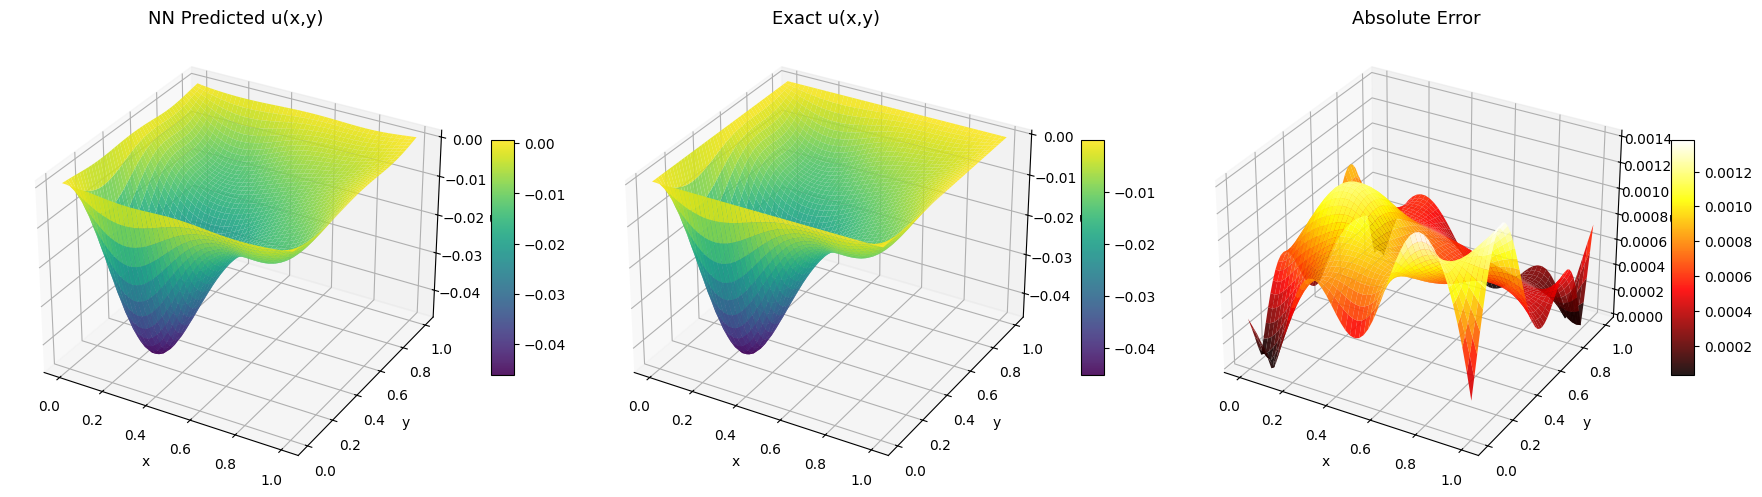

Graph: 3


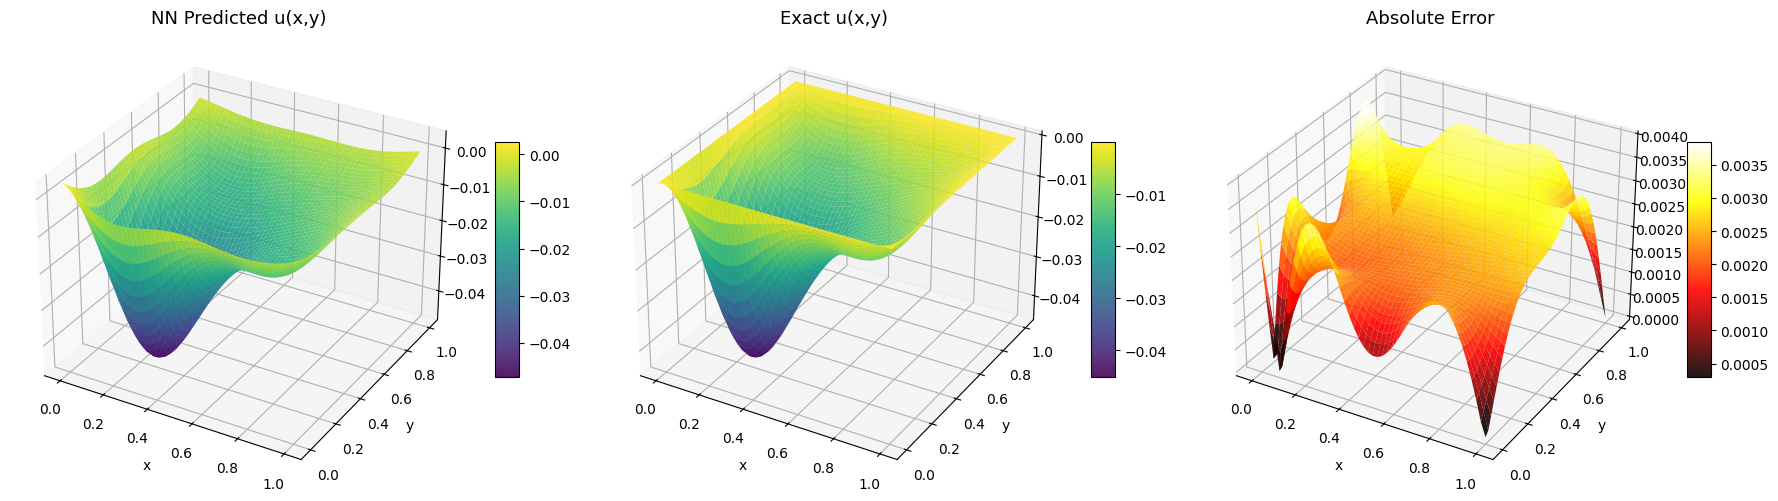

Graph: 4


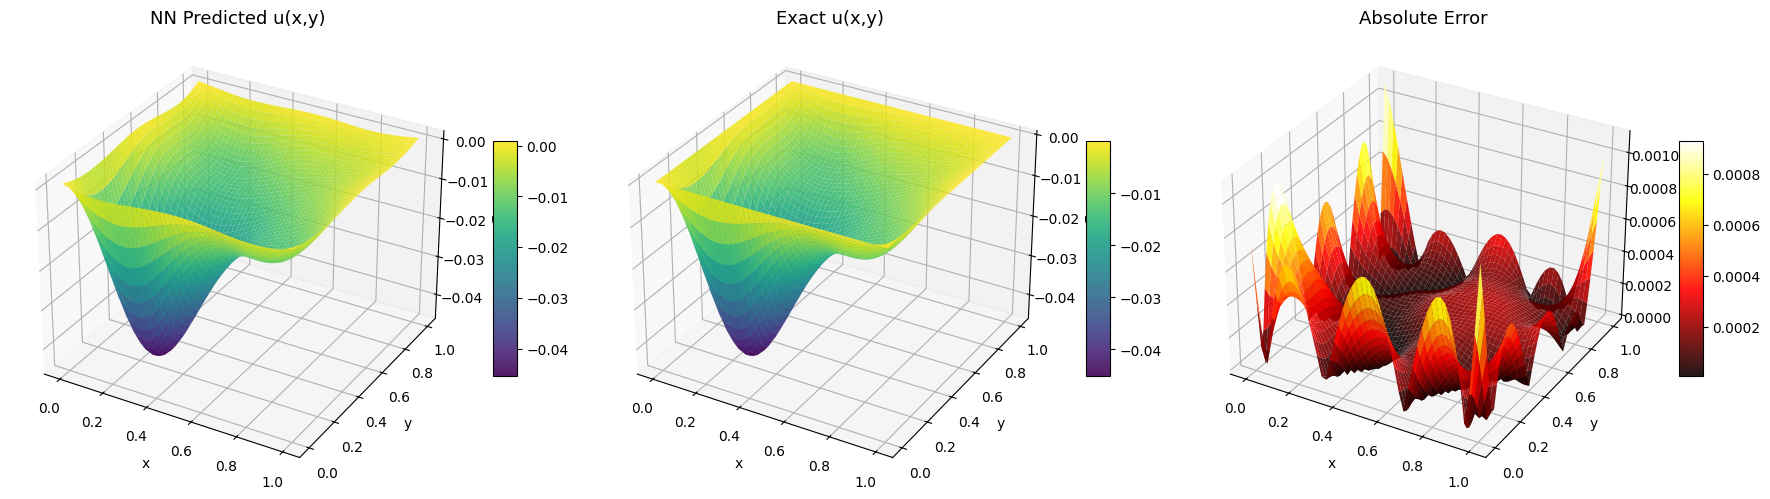

In [8]:
iterations = 10000
epochs = 4
pts = 75

for epoch in range(epochs):

    u_bc = torch.zeros(pts,1).to(DEVICE).requires_grad_()
    
    x_zeros = torch.zeros_like(u_bc).to(DEVICE).requires_grad_()
    x_ones = torch.ones_like(u_bc).to(DEVICE).requires_grad_()
    
    y_zeros = torch.zeros_like(u_bc).to(DEVICE).requires_grad_()
    y_ones = torch.ones_like(u_bc).to(DEVICE).requires_grad_()
    
    for iter_ in range(iterations):
        optimizer.zero_grad()
        
        # Loss based on boundary conditions --------------------------------------------------------------
        # need to be recalculated every run since they always contain a random collocation of points 
        
        boundary_cond_dict = boundary_cond(pts)
        
        x_bc1, x_bc3 = boundary_cond_dict["x_bc_values"]
        x_bc1, x_bc3 = x_bc1.to(DEVICE).requires_grad_(), x_bc3.to(DEVICE).requires_grad_()
        x_bc2, x_bc4 = x_ones, x_zeros
        
        y_bc2, y_bc4 = boundary_cond_dict["y_bc_values"]
        y_bc2, y_bc4 = y_bc2.to(DEVICE).requires_grad_(), y_bc4.to(DEVICE).requires_grad_()
        y_bc1, y_bc3 = y_zeros, y_ones
        
        u_pred_bc1 = NN(x_bc1, y_bc1)
        u_pred_bc2 = NN(x_bc2, y_bc2)
        u_pred_bc3 = NN(x_bc3, y_bc3)
        u_pred_bc4 = NN(x_bc4, y_bc4)
    
        mse_bc1_loss = loss_func(u_pred_bc1, u_bc)
        mse_bc2_loss = loss_func(u_pred_bc2, u_bc)
        mse_bc3_loss = loss_func(u_pred_bc3, u_bc)
        mse_bc4_loss = loss_func(u_pred_bc4, u_bc)
        
        mse_bc_loss = mse_bc1_loss + mse_bc2_loss + mse_bc3_loss + mse_bc4_loss
    
        # Loss based on PDE -----------------------------------------------------------------------------
    
        x = torch.rand(pts,1).to(DEVICE).requires_grad_()
        y = torch.rand(pts,1).to(DEVICE).requires_grad_()
        
        u_pred = NN(x,y)
        g = f(x,y)[0].to(DEVICE).requires_grad_()  #f = torch.zeros(1,n)
        #f = f(X,Y)[0].to(DEVICE).requires_grad_()  f = torch.zeros(n,n) 
        
        mse_loss = pde_loss(u_pred,g,x,y)
    
        # Total loss -------------------------------------------------------------------------------------
        lambda1 = 1e-2 # 1e-3
        if not(epoch%2 == 0): 
            LOSS = lambda1*mse_loss + mse_bc_loss
        else:
            LOSS = mse_loss + mse_bc_loss
        #LOSS = mse_loss + mse_bc_loss
        LOSS.backward()
            
        #
        #print("Iteration: ", epoch , "\n mse_bc1_loss: ", LOSS)
        
        optimizer.step()
    
        #with torch.autograd.no_grad():
            #print(epoch,"pde_loss with weight:",lambda1*mse_loss, "\t bc_loss:" , mse_bc_loss)
    
    plot_solution(curr_run = epoch + 1)

In [ ]:
def main():
    n = 50
    
    pass
    